In [2]:
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from uncertainties import ufloat
from ctypes import c_double
from pathlib import Path
import pickle

# import ROOT
# ROOT.EnableImplicitMT()    # Tells ROOT to go parallel

/groups/hephy/cms/alikaan.gueven/conda/envs/SDV/lib/python3.11/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [52]:
# HISTDIR = Path('/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/vtx_PART_1111best_valloss_epoch_test_deltaphi/tables')
# SAMPLE = 'C1N2ML_M500_485_ct2_2018_MET400_SP_evt_leading_vtx_SP_dphiMET_vs_SP_Max_ML_score'
HISTDIR = Path('/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/vtx_PART_1111best_valloss_epoch_test2/tables')
SAMPLE = 'C1N2ML_M500_485_ct20_2018_SP2_evt_MET_pt_corr_vs_SP2_Max_ML_score'
# SAMPLE = 'stopML_M1000_985_ct20_2018_SP1_evt_MET_pt_corr_vs_SP1_Max_ML_score'
loCut_key = '0.00,0.50'

TABLE = 'gridsearch_disco.pkl'

TABLE_PATH = HISTDIR / SAMPLE / TABLE

with open(TABLE_PATH, 'rb') as f:
    table = pickle.load(f)

print('Keys in the loaded table:')
for key in table.keys():
    print(key)


Keys in the loaded table:
0.00,0.50


In [53]:
def pick_ticks(vals, n=6):
    vals = np.asarray(list(vals), dtype=float)
    if len(vals) <= n:
        return vals
    idx = np.unique(np.round(np.linspace(0, len(vals)-1, n)).astype(int))
    idx[0] = 0
    idx[-1] = len(vals) - 1
    return vals[idx]

def edges_from_centers(c):
    c = np.asarray(c, dtype=float)
    d = np.diff(c)
    e = np.empty(len(c) + 1)
    e[1:-1] = c[:-1] + d / 2
    e[0]  = c[0]  - d[0] / 2
    e[-1] = c[-1] + d[-1] / 2
    return e

In [54]:
# df = table[loCut_key]['Z_B'].iloc[:-1, :-1].copy()
# X_b = df.loc[df.index > 0, df.columns > 0.995]

# x = X_b.index.to_numpy(dtype=float)
# y = X_b.columns.to_numpy(dtype=float)

# x_edges = edges_from_centers(x)     # len = Nx + 1
# y_edges = edges_from_centers(y)     # len = Ny + 1

# C = X_b.T.to_numpy()                # (Ny, Nx)

# fig, ax = plt.subplots(figsize=(7, 5))
# pcm = ax.pcolormesh(
#     x_edges, y_edges, C,
#     cmap="Blues_r", shading="flat"
# )

# ax.set_xticks(pick_ticks(x, 6))
# ax.set_yticks(pick_ticks(y, 6))

# ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
# ax.set_yticklabels([f"{v:.5f}" for v in ax.get_yticks()])

# cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
# cbar.ax.set_ylabel(r'Asimov Significance')

# ax.set_xlabel("leading_vtx_dphiMET cut")
# ax.set_ylabel("ML cut")
# ax.set_title("Z_B in 2018 MC")

# fig.tight_layout()
# plt.show()

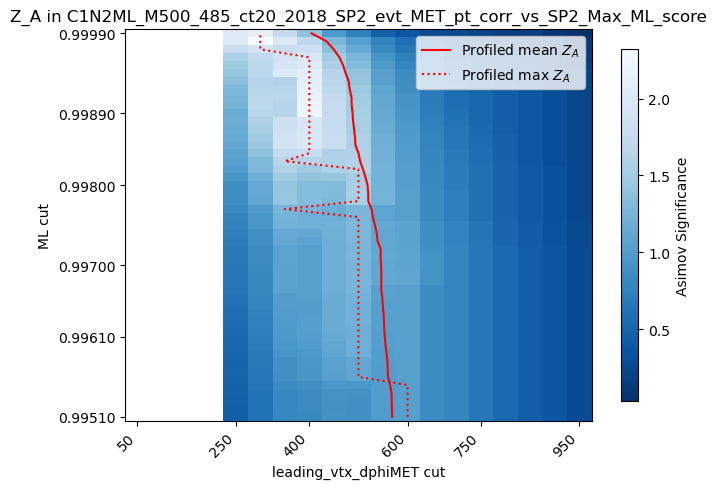

In [55]:
import numpy as np
import matplotlib.pyplot as plt

var = "Z_A"

df  = table[loCut_key][var].iloc[:-1, :-1].copy()
X_b = df.loc[df.index > 0, df.columns > 0.995]
X_b[X_b.index <= 200] = np.nan

x = X_b.index.to_numpy(dtype=float)       # (Nx,)
y = X_b.columns.to_numpy(dtype=float)     # (Ny,)

x_edges = edges_from_centers(x)
y_edges = edges_from_centers(y)

C = X_b.T.to_numpy()                      # (Ny, Nx)

fig, ax = plt.subplots(figsize=(7, 5))
pcm = ax.pcolormesh(x_edges, y_edges, C, cmap="Blues_r", shading="flat")

# ---------- mean-logic curve: <x> weighted by z ----------
W = np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)

# Optional if you don't want negative weights:
# W = np.clip(W, 0.0, None)
# W = np.abs(W)

den = W.sum(axis=1)  # (Ny,)
x_mean = np.divide(
    (W * x[None, :]).sum(axis=1),
    den,
    out=np.full_like(den, np.nan, dtype=float),
    where=den > 0
)

# ---------- max-logic curve: argmax_x z ----------
Cmax = np.nan_to_num(C, nan=-np.inf, posinf=np.inf, neginf=-np.inf)
imax = np.argmax(Cmax, axis=1)
row_max = np.max(Cmax, axis=1)
valid = row_max > -np.inf

x_max = np.full(len(y), np.nan, dtype=float)
x_max[valid] = x[imax[valid]]

# ---------- draw both curves ----------
ax.plot(x_mean, y, "-", color="r", lw=1.5, label=rf"Profiled mean ${var}$")
ax.plot(x_max,  y, ":", color="r", lw=1.5, label=rf"Profiled max ${var}$")

# ---------- axes styling ----------
ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.5f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r"Asimov Significance")

ax.set_xlabel("leading_vtx_dphiMET cut")
ax.set_ylabel("ML cut")
ax.set_title(f"{var} in {SAMPLE}")

ax.legend(frameon=True, loc="best")

fig.tight_layout()
plt.show()


In [45]:
table[loCut_key]['bkg_NA'].loc[:,0.5:]

,0.5000,0.5001,0.5002,0.5003,0.5004,0.5005,0.5006,0.5007,0.5008,0.5009,...,0.9991,0.9992,0.9993,0.9994,0.9995,0.9996,0.9997,0.9998,0.9999,1.0000
0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50.0,NaN,158122.017984,158089.167910,158049.487306,157999.230669,157999.230669,157887.544999,157852.961185,157805.031737,157762.277899,...,96.659067,82.042840,74.411722,62.568130,51.458233,39.033599,22.985200,13.620878,4.044805,0.0
100.0,NaN,158122.017984,158089.167910,158049.487306,157999.230669,157999.230669,157887.544999,157852.961185,157805.031737,157762.277899,...,96.659067,82.042840,74.411722,62.568130,51.458233,39.033599,22.985200,13.620878,4.044805,0.0
150.0,NaN,158122.017984,158089.167910,158049.487306,157999.230669,157999.230669,157887.544999,157852.961185,157805.031737,157762.277899,...,96.659067,82.042840,74.411722,62.568130,51.458233,39.033599,22.985200,13.620878,4.044805,0.0
200.0,NaN,158122.017984,158089.167910,158049.487306,157999.230669,157999.230669,157887.544999,157852.961185,157805.031737,157762.277899,...,96.659067,82.042840,74.411722,62.568130,51.458233,39.033599,22.985200,13.620878,4.044805,0.0
250.0,NaN,62501.659131,62485.465274,62465.608178,62453.802514,62453.802514,62422.750528,62405.793563,62385.059369,62367.235016,...,43.994446,39.319636,34.610109,29.762576,25.818267,19.575166,11.157878,6.817507,1.047584,0.0
300.0,NaN,26583.644151,26574.379068,26563.991753,26558.346505,26558.346505,26542.929715,26535.918641,26529.149404,26524.343619,...,19.652471,17.415306,16.502798,13.671397,12.503212,8.970916,5.550140,3.465614,0.987603,0.0
350.0,NaN,12480.940151,12477.274967,12472.779267,12468.899797,12468.899797,12462.401299,12458.897354,12454.800649,12452.199905,...,3.925839,2.284920,1.952045,1.855900,1.602073,0.404127,0.087988,0.040233,-0.482001,0.0
400.0,NaN,6372.978784,6370.642577,6368.786549,6367.272481,6367.272481,6364.966784,6363.238464,6360.819249,6359.572410,...,3.394442,1.843452,1.662933,0.772251,0.584576,0.209349,0.023834,-0.411940,-0.482001,0.0
450.0,NaN,3487.923534,3486.411743,3485.188393,3484.332822,3484.332822,3482.736430,3481.691116,3480.453047,3480.421557,...,1.808865,1.274991,1.173234,0.362391,0.289533,-0.044199,-0.149777,-0.411940,-0.482001,0.0


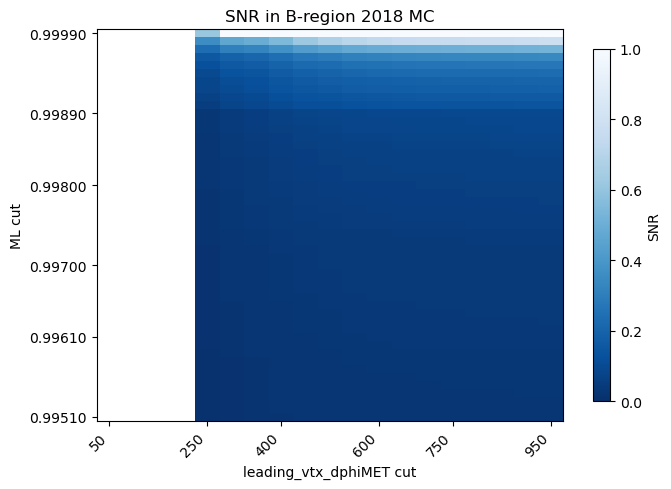

In [45]:
df = (table[loCut_key]['sig_NB'] / table[loCut_key]['bkg_NB']).iloc[:-1, :-1].copy()
X_b = df.loc[df.index > 0, df.columns > 0.995]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)

fig, ax = plt.subplots(figsize=(7, 5))
pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="Blues_r", shading="flat",
    vmin=0, vmax=1
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.5f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'SNR')

ax.set_xlabel("leading_vtx_dphiMET cut")
ax.set_ylabel("ML cut")
ax.set_title("SNR in B-region 2018 MC")

fig.tight_layout()
plt.show()

In [91]:
df = table[loCut_key]['bkg_NA'].iloc[:-2, :-1].copy()
df.loc[df.index > 0, df.columns > 0.998]

y_cut,0.9982,0.9984,0.9986,0.9988,0.9990,0.9992,0.9994,0.9996,0.9998
x_cut,,,,,,,,,
0.1,5.555896,4.087978,3.731036,3.255035,2.197923,1.260971,0.277472,-0.119193,-0.668625
0.2,5.366688,3.898769,3.541827,3.135379,2.078267,1.141315,0.157815,-0.199864,-0.708685
0.3,5.248847,3.793388,3.436447,3.029998,2.011410,1.074458,0.130427,-0.227253,-0.736074
0.4,5.248847,3.793388,3.436447,3.029998,2.011410,1.074458,0.130427,-0.227253,-0.736074
0.5,5.028555,3.573097,3.289653,2.914872,1.934267,0.999171,0.055139,-0.264691,-0.736074
0.6,4.728700,3.304424,3.020981,2.646200,1.665594,0.730499,0.019332,-0.300499,-0.771881
0.7,4.626014,3.201739,2.949283,2.574501,1.593896,0.658800,0.019332,-0.300499,-0.771881
0.8,4.547902,3.163031,2.910575,2.535793,1.555188,0.658800,0.019332,-0.300499,-0.771881
0.9,3.843777,3.055836,2.908717,2.533936,1.555188,0.658800,0.019332,-0.300499,-0.771881


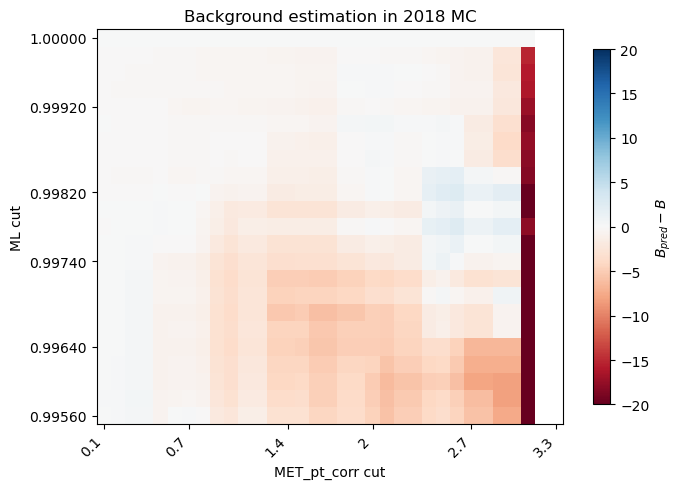

In [72]:
X_b = table[loCut_key]['bkg_NA']*table[loCut_key]['bkg_ND']/table[loCut_key]['bkg_NC'] - table[loCut_key]['bkg_NB'] 
X_b = X_b.loc[X_b.index > 0, X_b.columns > 0.9955]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)
# absmax = np.nanmax(np.abs(C))
absmax = 20

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-absmax, vmax=+absmax, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.5f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$B_{pred} - B$')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


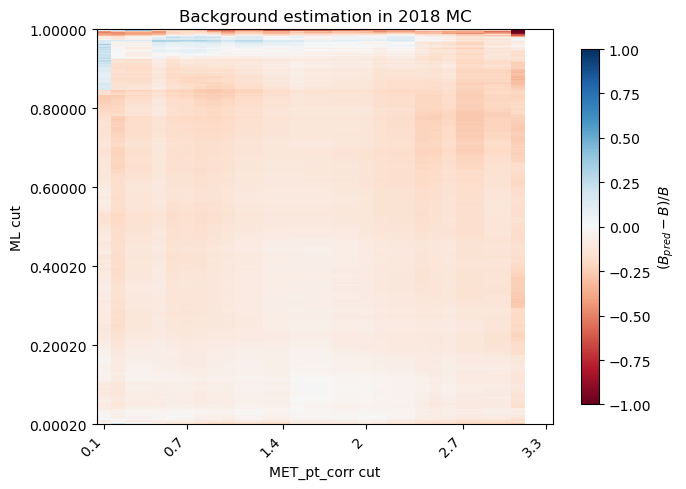

In [73]:
X_b = table[loCut_key]['bkg_NA']*table[loCut_key]['bkg_ND']/table[loCut_key]['bkg_NC'] - table[loCut_key]['bkg_NB'] 
X_b /= table[loCut_key]['bkg_NB']
X_b = X_b.loc[X_b.index > 0, X_b.columns > 0.]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-1, vmax=+1, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.5f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$(B_{pred} - B) / B$')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


In [74]:
X_b = table[loCut_key]['bkg_NA']*table[loCut_key]['bkg_ND']/table[loCut_key]['bkg_NC'] - table[loCut_key]['bkg_NB'] 
X_b /= table[loCut_key]['bkg_NB']
X_b = X_b.loc[X_b.index > 0, X_b.columns > 0]
X_b.mean().iloc[:-10].mean()

-0.11658561594186423

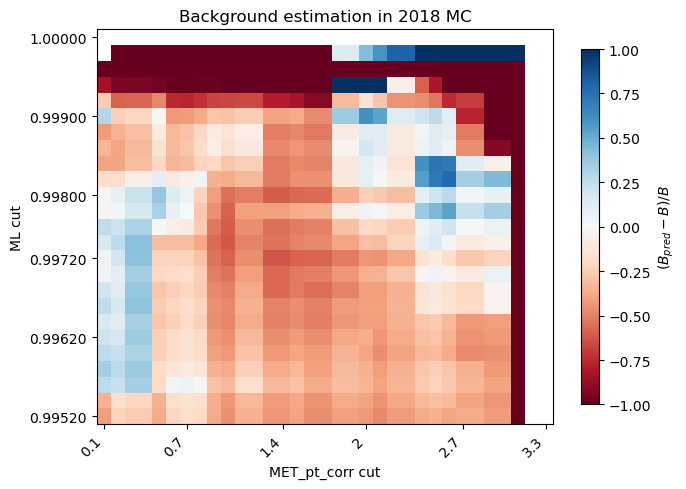

In [75]:
X_b = table[loCut_key]['bkg_NA']*table[loCut_key]['bkg_ND']/table[loCut_key]['bkg_NC'] - table[loCut_key]['bkg_NB'] 
X_b /= table[loCut_key]['bkg_NB']
X_b = X_b.loc[X_b.index > 0, X_b.columns > 0.995]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-1, vmax=+1, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.5f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$(B_{pred} - B) / B$')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


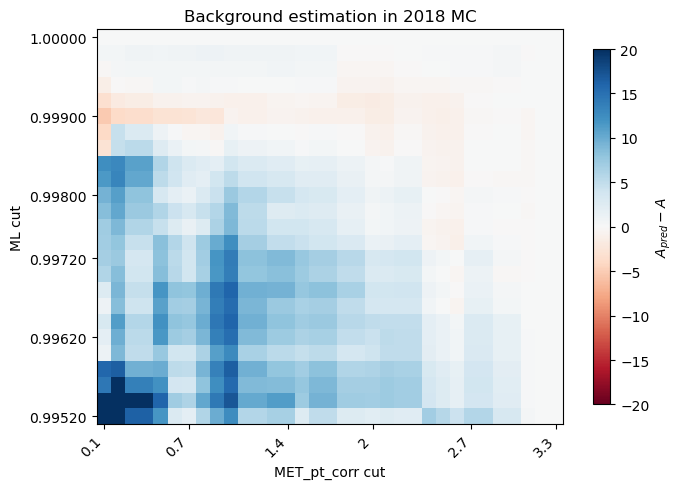

In [41]:
X_b = -table[loCut_key]['delta_A']
X_b = X_b.loc[X_b.index > 0, X_b.columns > 0.995]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)
# absmax = np.nanmax(np.abs(C))
absmax = 20

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-absmax, vmax=+absmax, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.5f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$A_{pred} - A$')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


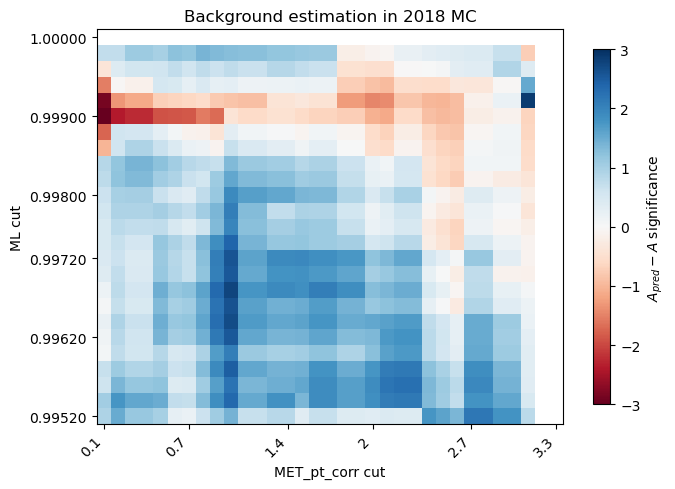

In [42]:
X_b = -table[loCut_key]['delta_A'] / table[loCut_key]['delta_A_unc']
X_b = X_b.loc[X_b.index > 0, X_b.columns > 0.995]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-3, vmax=3, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.5f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$A_{pred} - A$ significance')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


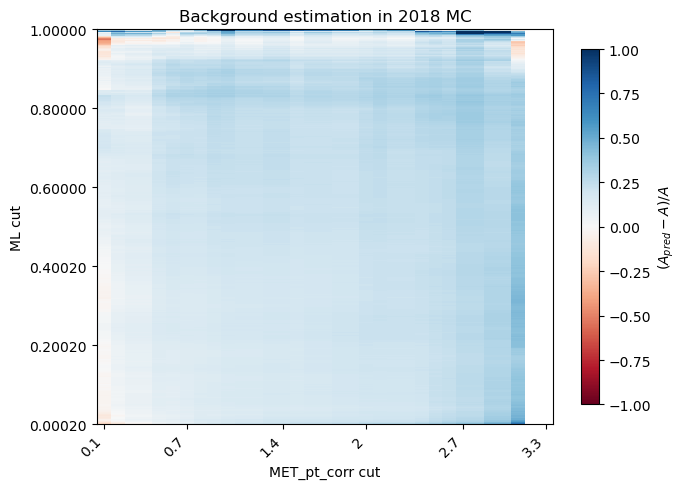

In [43]:
X_b = -table[loCut_key]['delta_A'] / table[loCut_key]['bkg_NA']
X_b = X_b.loc[X_b.index > 0, X_b.columns > 0]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-1, vmax=+1, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.5f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$(A_{pred} - A) / A$')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


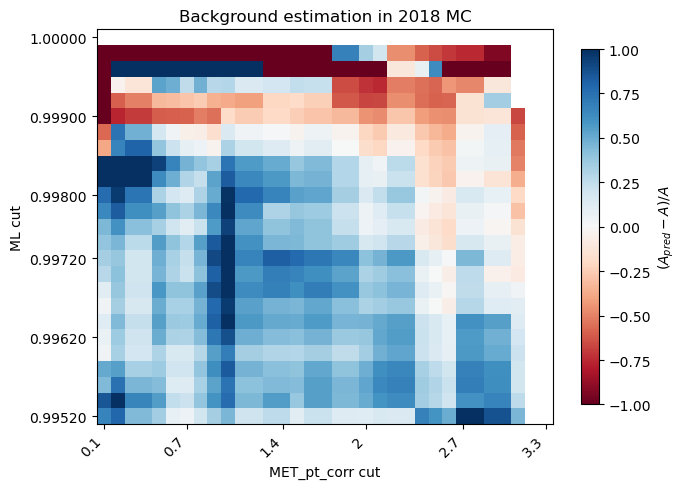

In [44]:
X_b = -table[loCut_key]['delta_A'] / table[loCut_key]['bkg_NA']
X_b = X_b.loc[X_b.index > 0, X_b.columns > 0.995]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-1, vmax=+1, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.5f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$(A_{pred} - A) / A$')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


In [14]:
table[loCut_key]['bkg_NA'].loc[100:600,0.999:]

,0.999


In [15]:
table[loCut_key]['bkg_NA_unc'].loc[100:600,0.999:]

,0.999


In [16]:
table[loCut_key]['sig_NA'].loc[100:600,0.999:]

,0.999


In [17]:
table[loCut_key]['Z_A'].loc[100:600,1:0.999:-1].T

""
0.999


In [18]:
-table[loCut_key]['delta_A'] / table[loCut_key]['bkg_NA']

,0.001,0.002,0.003,0.004,0.005,0.006,0.007,0.008,0.009,0.010,...,0.990,0.991,0.992,0.993,0.994,0.995,0.996,0.997,0.998,0.999
-1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-9.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-8.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-7.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-6.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-5.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-4.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-3.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-2.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-1.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
table[loCut_key]['bkg_NA'].loc[:,X_b.columns > 0.995]

,0.980,0.981,0.982,0.983,0.984,0.985,0.986,0.987,0.988,0.989,0.990,0.991,0.992,0.993,0.994,0.995,0.996,0.997,0.998,0.999
-1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-9.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-8.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-7.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-6.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-5.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-4.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-3.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-2.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-1.000000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
table[loCut_key]['noncl'].loc[X_b.index > 0,X_b.columns > 0.995] - table[loCut_key]['noncl_unc'].loc[X_b.index > 0,X_b.columns > 0.995]

,0.980,0.981,0.982,0.983,0.984,0.985,0.986,0.987,0.988,0.989,0.990,0.991,0.992,0.993,0.994,0.995,0.996,0.997,0.998,0.999


In [ ]:
def plot_updown(Z_noncl_minus, Z_noncl, Z_noncl_plus, suptitle):
    # Common contour levels
    base_levels = [-0.30, 0.30]
    global_max = np.nanmax([
        np.nanmax(Z_noncl_minus.values),
        np.nanmax(Z_noncl.values),
        np.nanmax(Z_noncl_plus.values)
    ])
    levels = [lv for lv in base_levels if lv <= global_max]

    # Shared color scale
    vmin =  0
    vmax =  1

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    fig.suptitle(suptitle)

    # ---------------- LEFT: noncl - noncl_unc ----------------
    ax = axes[0]
    ax.set_title("noncl − noncl_unc")
    pcm0 = ax.pcolormesh(
        Z_noncl_minus.index, Z_noncl_minus.columns, Z_noncl_minus.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont0 = ax.contour(
            Z_noncl_minus.index, Z_noncl_minus.columns, Z_noncl_minus.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont0, fontsize="smaller")
    # ax.set_xlim(0., 0.5)
    # ax.set_ylim(0., 0.5)
    # ax.set_xlabel("leading_vtx_ML1 cut")
    # ax.set_ylabel("leading_vtx_ML2 cut")

    # ---------------- MIDDLE: noncl ----------------
    ax = axes[1]
    ax.set_title("noncl")
    pcm1 = ax.pcolormesh(
        Z_noncl.index, Z_noncl.columns, Z_noncl.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont1 = ax.contour(
            Z_noncl.index, Z_noncl.columns, Z_noncl.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont1, fontsize="smaller")
    # ax.set_xlim(0., 0.5)
    # ax.set_ylim(0., 0.5)
    # ax.set_xlabel("leading_vtx_ML1 cut")

    # ---------------- RIGHT: noncl + noncl_unc ----------------
    ax = axes[2]
    ax.set_title("noncl + noncl_unc")
    pcm2 = ax.pcolormesh(
        Z_noncl_plus.index, Z_noncl_plus.columns, Z_noncl_plus.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont2 = ax.contour(
            Z_noncl_plus.index, Z_noncl_plus.columns, Z_noncl_plus.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont2, fontsize="smaller")
    # ax.set_xlim(0., 0.5)
    # ax.set_ylim(0., 0.5)
    # ax.set_xlabel("leading_vtx_ML1 cut")

    # Shared colorbar
    cbar = fig.colorbar(pcm2, ax=axes.ravel().tolist(), shrink=0.90)
    cbar.ax.set_ylabel(r"$(A - A_{pred}) / A$")

    plt.show()

key = loCut_key
noncl          =  table[key]['noncl'].loc[X_b.index > 0,X_b.columns > 0.995]
noncl_plus1s   =  table[key]['noncl'].loc[X_b.index > 0,X_b.columns > 0.995] + table[key]['noncl_unc'].loc[X_b.index > 0,X_b.columns > 0.995]
noncl_minus1s  =  table[key]['noncl'].loc[X_b.index > 0,X_b.columns > 0.995] - table[key]['noncl_unc'].loc[X_b.index > 0,X_b.columns > 0.995]
plot_updown(noncl_minus1s, noncl, noncl_plus1s, suptitle=f"Non-closure for presel + SP1 Plane in MC ({key})")

ValueError: zero-size array to reduction operation fmax which has no identity

### Overall Picture

In [ ]:
key = loCut_key
X_b = -table[key]['delta_A']
X_b = X_b.loc[X_b.index > 0,:]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)
absmax = np.nanmax(np.abs(C))

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-absmax, vmax=+absmax, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.5f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$A_{pred} - A$')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
X_b = -table[loCut_key]['delta_A'] / table[loCut_key]['delta_A_unc']
X_b = X_b.loc[X_b.index > 0, :]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-3, vmax=3, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.5f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$A_{pred} - A$ significance')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
key = loCut_key
X_b = -table[key]['delta_A'] / table[key]['bkg_NA']
X_b = X_b.loc[X_b.index > 0, :]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-1, vmax=+1, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.5f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$(A_{pred} - A) / A$')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


IndexError: index 0 is out of bounds for axis 0 with size 0

### Significance

In [ ]:
import matplotlib.ticker as mtick



key = loCut_key
X_b = table[key]['Z_A']
X_b = X_b.loc[X_b.index > 0, X_b.columns > 0.995]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)
absmax = np.nanmax(np.abs(C))

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="Blues_r", vmin=0, vmax=+absmax, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.5f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'Asimov Significance')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title(SAMPLE)

ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))

fig.tight_layout()
plt.show()


IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
X_b = table[loCut_key]['Z_noncl_A']
X_b = X_b.loc[X_b.index > 0, X_b.columns > 0.995]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)
absmax = np.nanmax(np.abs(C))

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="Blues_r", vmin=0, vmax=+absmax, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.5f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'Asimov Significance')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title(SAMPLE)

ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))

fig.tight_layout()
plt.show()


IndexError: index 0 is out of bounds for axis 0 with size 0

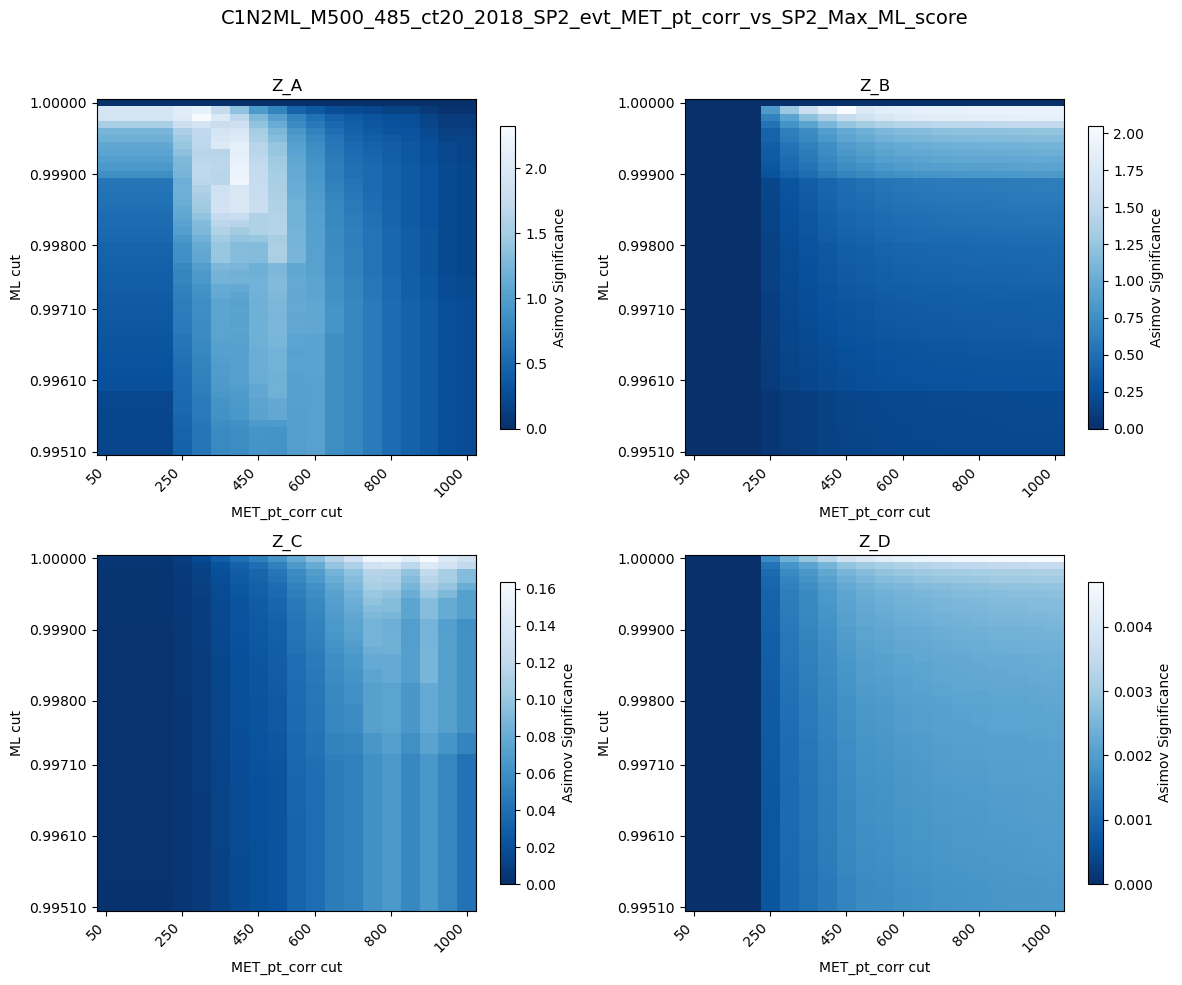

In [ ]:
import matplotlib.ticker as mtick

Z_KEYS = [var, "Z_B", "Z_C", "Z_D"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, ZK in zip(axes, Z_KEYS):

    X_b = table[key][ZK]
    X_b = X_b.loc[X_b.index > 0, X_b.columns > 0.995]

    x = X_b.index.to_numpy(dtype=float)
    y = X_b.columns.to_numpy(dtype=float)

    x_edges = edges_from_centers(x)
    y_edges = edges_from_centers(y)

    C = X_b.T.to_numpy()   # (Ny, Nx)
    absmax = np.nanmax(np.abs(C))

    pcm = ax.pcolormesh(
        x_edges, y_edges, C,
        cmap="Blues_r",
        vmin=0,
        vmax=absmax,
        shading="flat"
    )

    ax.set_xticks(pick_ticks(x, 6))
    ax.set_yticks(pick_ticks(y, 6))

    ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()],
                       rotation=45, ha="right")
    ax.set_yticklabels([f"{v:.5f}" for v in ax.get_yticks()])

    ax.set_xlabel("MET_pt_corr cut")
    ax.set_ylabel("ML cut")
    ax.set_title(ZK)

    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))

    cbar = fig.colorbar(pcm, ax=ax, shrink=0.85)
    cbar.ax.set_ylabel("Asimov Significance")

fig.suptitle(SAMPLE, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
table[key]['Z_A'].loc[X_b.index > 0, 0.999:]

,0.999


In [56]:
x_max, y_max = table[key]['Z_A'].loc[X_b.index > 0, 0.999:].stack().idxmax()
print('Cut at x: ', x_max)
print('Cut at y: ', y_max)
print()

print('B signif.: \t', f"{table[key]['Z_B'].loc[x_max, y_max]:.3f}")
print('B sig yield: \t',    f"{table[key]['sig_NB'].loc[x_max, y_max]:.3f}")
print('B bkg yield: \t',    f"{table[key]['bkg_NB'].loc[x_max, y_max]:.3f}")

IndexError: Boolean index has wrong length: 20 instead of 21

In [57]:
x_cut, y_cut = 400, 0.9992000000000001
print('Cut at x: ', x_cut)
print('Cut at y: ', y_cut)
print()

print('B signif.: \t', f"{table[key]['Z_B'].loc[x_cut, y_cut]:.3f}")
print('B sig yield: \t',    f"{table[key]['sig_NB'].loc[x_cut, y_cut]:.3f}")
print('B bkg yield: \t',    f"{table[key]['bkg_NB'].loc[x_cut, y_cut]:.3f}")

Cut at x:  400
Cut at y:  0.9992000000000001



KeyError: 0.9992000000000001

IndexError: index 0 is out of bounds for axis 0 with size 0

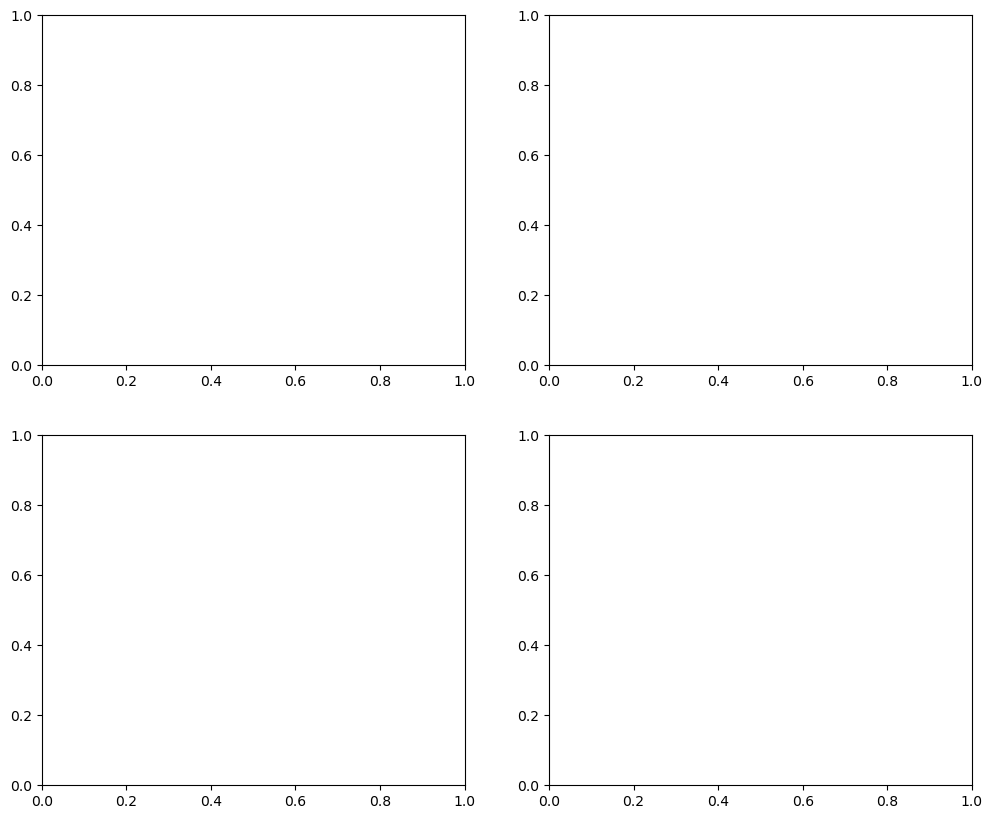

In [ ]:
sig_contamination_upper_limit = 0.20

blinding_mask = (table[key]['sig_NB'] / table[key]['bkg_NB'] < sig_contamination_upper_limit)
import matplotlib.ticker as mtick

Z_KEYS = [var, "Z_B", "Z_C", "Z_D"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, ZK in zip(axes, Z_KEYS):

    X_b = table[key][ZK][blinding_mask]
    X_b = X_b.loc[X_b.index > 0, X_b.columns > 0.995]

    x = X_b.index.to_numpy(dtype=float)
    y = X_b.columns.to_numpy(dtype=float)

    x_edges = edges_from_centers(x)
    y_edges = edges_from_centers(y)

    C = X_b.T.to_numpy()
    C = np.ma.masked_invalid(C)

    absmax = np.nanmax(np.abs(C))

    cmap = plt.cm.Blues_r.copy()
    cmap.set_bad("black")

    pcm = ax.pcolormesh(
        x_edges, y_edges, C,
        cmap=cmap,
        vmin=0,
        vmax=absmax,
        shading="flat"
    )

    ax.text(
        0.7, 0.8, f"Signal Contamination > {100 * sig_contamination_upper_limit:.0f}%\nin B region",
        transform=ax.transAxes,
        ha="center", va="center",
        color="white",
        fontsize=9,
        fontweight="bold",
        fontfamily="sans-serif",
        fontname="Nimbus Sans",
        bbox=dict(facecolor="black", edgecolor="none", boxstyle="round,pad=0.4"),
        zorder=10
    )

    ax.set_xticks(pick_ticks(x, 6))
    ax.set_yticks(pick_ticks(y, 6))

    ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()],
                       rotation=45, ha="right")
    ax.set_yticklabels([f"{v:.5f}" for v in ax.get_yticks()])

    ax.set_xlabel("MET_pt_corr cut")
    ax.set_ylabel("ML cut")
    ax.set_title(ZK)

    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))

    cbar = fig.colorbar(pcm, ax=ax, shrink=0.85)
    cbar.ax.set_ylabel("Asimov Significance")

fig.suptitle(SAMPLE, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
(table[key]['sig_NA'] / table[key]['bkg_NA']).loc[X_b.index > 0, 0.999:]

,0.9990,0.9991,0.9992,0.9993,0.9994,0.9995,0.9996,0.9997,0.9998,0.9999
250.0,0.498915,0.548054,0.644427,0.749555,0.814258,0.886099,1.178029,2.353075,3.758510,35.690422
300.0,0.853840,0.918288,1.103276,1.063974,1.104813,1.103293,1.621204,2.379052,4.203731,31.576408
350.0,2.541509,3.093524,-27.781240,-424.512569,7.195469,7.315887,-51.872984,-25.567651,-1186.278209,-6.992950
400.0,2.119075,2.137783,8.110481,10.796664,19.758359,30.981663,-41.243399,-27.696107,-8.047923,-5.445425
450.0,4.811099,4.752267,14.685201,25.505723,-56.424951,-55.209493,-10.711151,-10.308903,-6.251917,-4.247335
500.0,4.005073,3.940953,15.135409,23.274460,22.022223,21.597252,80.447866,76.406068,inf,inf
550.0,3.397676,3.329603,15.506290,28.544520,26.924020,26.595561,64.549035,60.507237,inf,inf
600.0,24.815542,24.149827,23.799391,inf,inf,inf,inf,inf,inf,inf
650.0,19.867941,19.508064,19.508064,inf,inf,inf,inf,inf,inf,inf
700.0,17.025985,16.666109,16.666109,inf,inf,inf,inf,inf,inf,inf


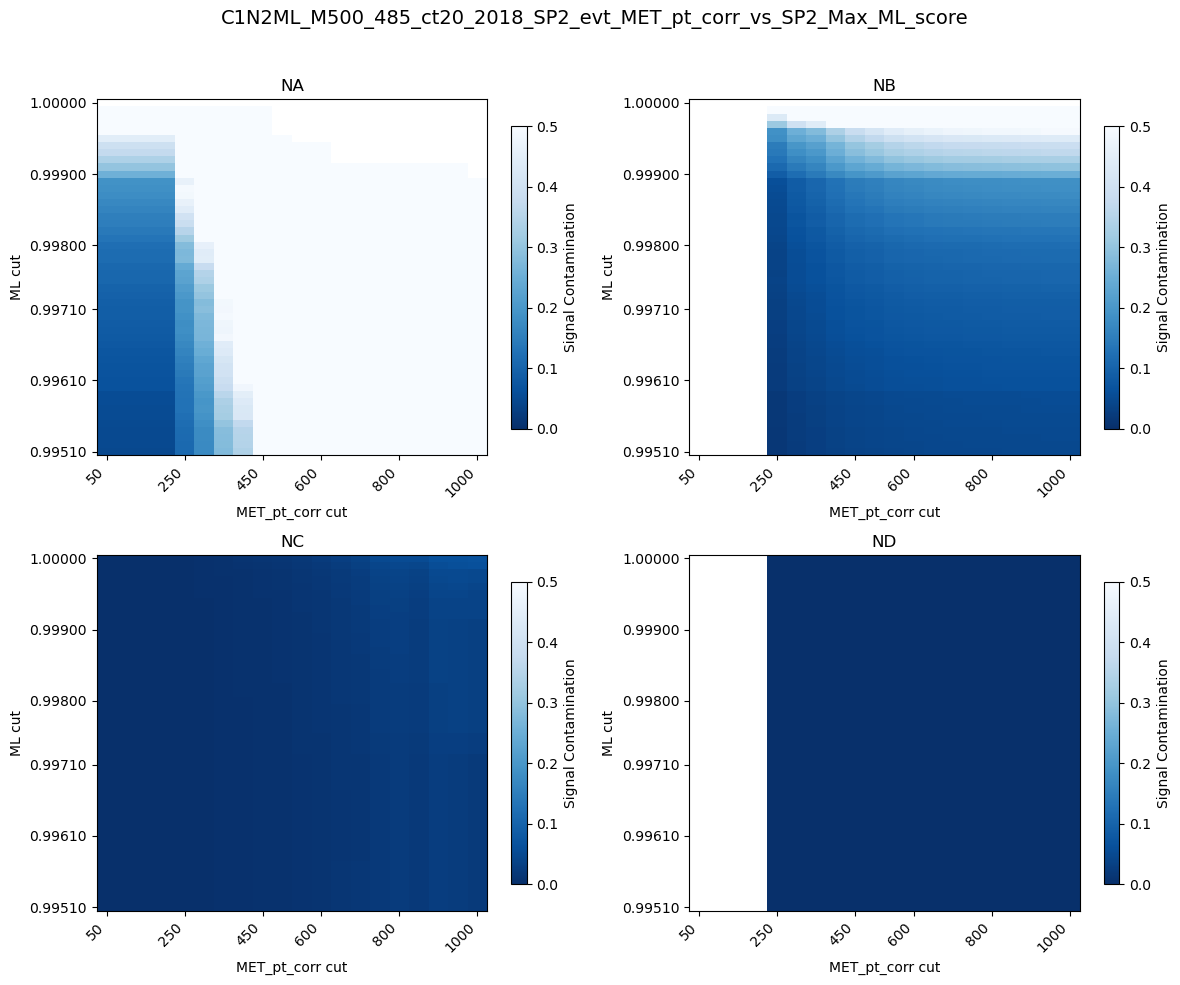

In [58]:
blinding_mask = (table[key]['sig_NB'] / table[key]['bkg_NB'] < 0.20)
import matplotlib.ticker as mtick

Z_KEYS = ["NA", "NB", "NC", "ND"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, ZK in zip(axes, Z_KEYS):

    s = table[key][f'sig_{ZK}']
    b = table[key][f'bkg_{ZK}']
    b[b < 0] = 0.1
    X_b = s / b
    X_b = X_b.loc[X_b.index > 0, X_b.columns > 0.995]

    x = X_b.index.to_numpy(dtype=float)
    y = X_b.columns.to_numpy(dtype=float)

    x_edges = edges_from_centers(x)
    y_edges = edges_from_centers(y)

    C = X_b.T.to_numpy()
    cmap = plt.cm.Blues_r.copy()
    pcm = ax.pcolormesh(
        x_edges, y_edges, C,
        cmap=cmap,
        vmin=0,
        vmax=0.5, # 50% signal contamination
        shading="flat"
    )

    ax.set_xticks(pick_ticks(x, 6))
    ax.set_yticks(pick_ticks(y, 6))

    ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()],
                       rotation=45, ha="right")
    ax.set_yticklabels([f"{v:.5f}" for v in ax.get_yticks()])

    ax.set_xlabel("MET_pt_corr cut")
    ax.set_ylabel("ML cut")
    ax.set_title(ZK)

    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))

    cbar = fig.colorbar(pcm, ax=ax, shrink=0.85)
    cbar.ax.set_ylabel("Signal Contamination")

fig.suptitle(SAMPLE, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
